**edX Courses Analysis (MIT vs Harvard)**

This notebook presents an exploratory and statistical analysis of **online courses** offered by **Harvard and MIT** through the **edX platform** between 2012 and 2016.
The analysis focuses on understanding patterns in learner engagement and certification rates across different course subjects.
Additionally, it aims to investigate whether there is a statistically significant **difference in certification rates between MIT and Harvard courses, particularly within the field of Computer Science.**

Importing Libraries

In [241]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy # Added this line to import the scipy module directly
import scipy.stats as stats
from scipy.stats import ttest_ind
# Removed: from scipy import stats (as it's redundant with import scipy and import scipy.stats as stats now)

# Style
sns.set(style="whitegrid")

Loading Dataset

In [242]:
url = "https://raw.githubusercontent.com/BasmallaReda/Data_Sense/main/Dataset.csv"
df = pd.read_csv(url)
df.head()

,Institution,Course Number,Launch Date,Course Title,Instructors,Course Subject,Year,Honor Code Certificates,Participants (Course Content Accessed),Audited (> 50% Course Content Accessed),...,% Certified of > 50% Course Content Accessed,% Played Video,% Posted in Forum,% Grade Higher Than Zero,Total Course Hours (Thousands),Median Hours for Certification,Median Age,% Male,% Female,% Bachelor's Degree or Higher
0,MITx,6.002x,09/05/2012,Circuits and Electronics,Khurram Afridi,"Science, Technology, Engineering, and Mathematics",1,1,36105,5431,...,54.98,83.2,8.17,28.97,418.94,64.45,26.0,88.28,11.72,60.68
1,MITx,6.00x,09/26/2012,Introduction to Computer Science and Programming,"Eric Grimson, John Guttag, Chris Terman",Computer Science,1,1,62709,8949,...,64.05,89.14,14.38,39.50,884.04,78.53,28.0,83.50,16.50,63.04
2,MITx,3.091x,10/09/2012,Introduction to Solid State Chemistry,Michael Cima,"Science, Technology, Engineering, and Mathematics",1,1,16663,2855,...,72.85,87.49,14.42,34.89,227.55,61.28,27.0,70.32,29.68,58.76
3,HarvardX,CS50x,10/15/2012,Introduction to Computer Science,"David Malan, Nate Hardison, Rob Bowden, Tommy ...",Computer Science,1,1,129400,12888,...,11.11,0,0.00,1.11,220.90,0.00,28.0,80.02,19.98,58.78
4,HarvardX,PH207x,10/15/2012,Health in Numbers: Quantitative Methods in Cli...,"Earl Francis Cook, Marcello Pagano","Government, Health, and Social Science",1,1,52521,10729,...,47.12,77.45,15.98,32.52,804.41,76.10,32.0,56.78,43.22,88.33


Data Overview

In [243]:
df.shape

(290, 23)

In [244]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 23 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Institution                                   290 non-null    object 
 1   Course Number                                 290 non-null    object 
 2   Launch Date                                   290 non-null    object 
 3   Course Title                                  290 non-null    object 
 4   Instructors                                   289 non-null    object 
 5   Course Subject                                290 non-null    object 
 6   Year                                          290 non-null    int64  
 7   Honor Code Certificates                       290 non-null    int64  
 8   Participants (Course Content Accessed)        290 non-null    int64  
 9   Audited (> 50% Course Content Accessed)       290 non-null    int

In [245]:
# Statistical Summary
df.describe()

,Year,Honor Code Certificates,Participants (Course Content Accessed),Audited (> 50% Course Content Accessed),Certified,% Audited,% Certified,% Certified of > 50% Course Content Accessed,% Posted in Forum,% Grade Higher Than Zero,Total Course Hours (Thousands),Median Hours for Certification,Median Age,% Male,% Female,% Bachelor's Degree or Higher
count,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000,290.000000
mean,3.172414,0.813793,15344.334483,2549.172414,843.810345,24.916966,7.782586,31.445655,9.347517,21.210379,94.981828,44.364552,29.300000,67.010690,32.989310,72.078724
std,0.906301,0.389946,28207.578733,3095.159969,1105.594372,15.883538,6.972437,19.751102,7.517141,13.411540,157.617610,43.953709,4.047897,15.843642,15.843642,10.256434
min,1.000000,0.000000,322.000000,187.000000,0.000000,2.630000,0.000000,0.000000,0.000000,0.000000,0.110000,0.000000,22.000000,25.240000,6.560000,44.950000
25%,3.000000,1.000000,3815.000000,755.250000,139.500000,14.215000,2.407500,13.400000,3.992500,10.590000,12.960000,12.242500,26.000000,54.170000,18.367500,64.515000
50%,3.000000,1.000000,7901.500000,1517.000000,395.500000,20.425000,5.950000,31.270000,7.245000,19.605000,37.710000,26.965000,29.000000,66.515000,33.485000,73.055000
75%,4.000000,1.000000,18038.250000,3383.000000,1201.750000,33.837500,10.687500,47.622500,14.107500,30.902500,97.225000,64.177500,31.000000,81.632500,45.830000,79.245000
max,4.000000,1.000000,301082.000000,25637.000000,5783.000000,83.960000,33.980000,77.090000,35.280000,52.350000,895.010000,251.820000,53.000000,93.440000,74.760000,98.110000


In [246]:
# Columns
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

Index(['institution', 'course_number', 'launch_date', 'course_title',
       'instructors', 'course_subject', 'year', 'honor_code_certificates',
       'participants_(course_content_accessed)',
       'audited_(>_50%_course_content_accessed)', 'certified', '%_audited',
       '%_certified', '%_certified_of_>_50%_course_content_accessed',
       '%_played_video', '%_posted_in_forum', '%_grade_higher_than_zero',
       'total_course_hours_(thousands)', 'median_hours_for_certification',
       'median_age', '%_male', '%_female', '%_bachelor's_degree_or_higher'],
      dtype='object')

In [247]:
# Rename columns to clean & professional names
df = df.rename(columns={
    "course_subject": "subject",
    "%_certified": "certified_percent",
    "%_audited": "audited_percent",
    "%_male": "male_percent",
    "%_female": "female_percent",
    "%_played_video": "video_percent",
    "%_posted_in_forum": "forum_percent",
    "%_grade_higher_than_zero": "active_percent",
    "%_bachelor's_degree_or_higher": "bachelor_percent",
    "total_course_hours_(thousands)": "total_hours",
    "median_hours_for_certification": "median_hours",
    "median_age": "age",
    "audited_(>_50%_course_content_accessed)": "audited_50_percent",
    "%_certified_of_>_50%_course_content_accessed": "certified_from_audited"
})


In [248]:
df.columns

Index(['institution', 'course_number', 'launch_date', 'course_title',
       'instructors', 'subject', 'year', 'honor_code_certificates',
       'participants_(course_content_accessed)', 'audited_50_percent',
       'certified', 'audited_percent', 'certified_percent',
       'certified_from_audited', 'video_percent', 'forum_percent',
       'active_percent', 'total_hours', 'median_hours', 'age', 'male_percent',
       'female_percent', 'bachelor_percent'],
      dtype='object')

In [249]:
# Convert important columns to numeric
numeric_cols = ["participants_(course_content_accessed)", "certified_percent", "audited_percent","male_percent", "female_percent", "total_hours", "median_hours", "age"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce') #coerce, if a value can be converted to a number, convert it, otherwise NaN

In this step, we handle missing values by removing rows with critical missing data and filling remaining values using the median to maintain data consistency.

In [250]:
# Check missing values
df.isnull().sum()

# Drop rows with critical missing values
df = df.dropna(subset=["participants_(course_content_accessed)", "certified_percent"])

# Fill remaining missing values using the median
df.fillna(df.median(numeric_only=True), inplace=True)

In [251]:
# Remove duplicate rows
df = df.drop_duplicates()

print("After removing duplicates:", df.shape)

After removing duplicates: (290, 23)


Outliers were detected and removed using the IQR method to ensure that extreme values do not negatively affect the analysis.

In [252]:
Q1 = df["certified_percent"].quantile(0.25)
Q3 = df["certified_percent"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["certified_percent"] >= lower) & (df["certified_percent"] <= upper)]

Data Cleaning

In [253]:
# Remove extra spaces from column names
# This prevents errors when accessing columns
df.columns = df.columns.str.strip()

In [254]:
df.isnull().sum()

,0
institution,0
course_number,0
launch_date,0
course_title,0
instructors,1
subject,0
year,0
honor_code_certificates,0
participants_(course_content_accessed),0
audited_50_percent,0


In [255]:
# Convert columns to numeric format
# Some values may be stored as text so we convert them to numbers
# errors='coerce' will turn invalid values into NaN instead of causing errors
df["certified_percent"] = pd.to_numeric(df["certified_percent"], errors='coerce')
df["participants_(course_content_accessed)"] = pd.to_numeric(df["participants_(course_content_accessed)"], errors='coerce')

In [256]:
# handrop el rows where data is NaN
df = df.dropna()
df.isnull().sum()

,0
institution,0
course_number,0
launch_date,0
course_title,0
instructors,0
subject,0
year,0
honor_code_certificates,0
participants_(course_content_accessed),0
audited_50_percent,0


In [257]:
# Check that everything looks correct after cleaning
df[["participants_(course_content_accessed)", "certified_percent"]].head()

,participants_(course_content_accessed),certified_percent
0,36105,8.32
1,62709,9.22
2,16663,12.49
3,129400,1.11
4,52521,9.64


#General data vizualisation graphs for all features and certification rates

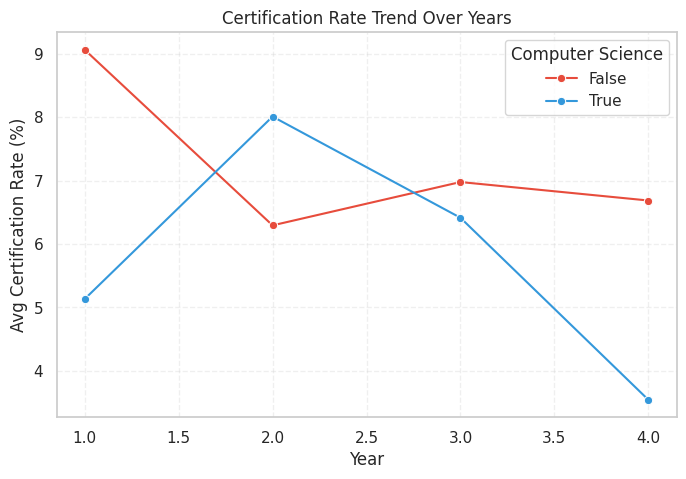

In [258]:
# average certification rate per year for CS/DS vs Other
df['is_cs'] = df['subject'].str.contains('Computer Science', case=False, na=False)# column for "CS subject?", char case does not matter, NaN not included
trend = df.groupby(['year', 'is_cs'])['certified_percent'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(data=trend, x='year', y='certified_percent', hue='is_cs', marker='o', palette=["#E74C3C", "#3498DB"] )
plt.title('Certification Rate Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Avg Certification Rate (%)')
plt.legend(title='Computer Science')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

Certification rates change over time, with noticeable fluctuations in Computer Science compared to more stable trends in other subjects.

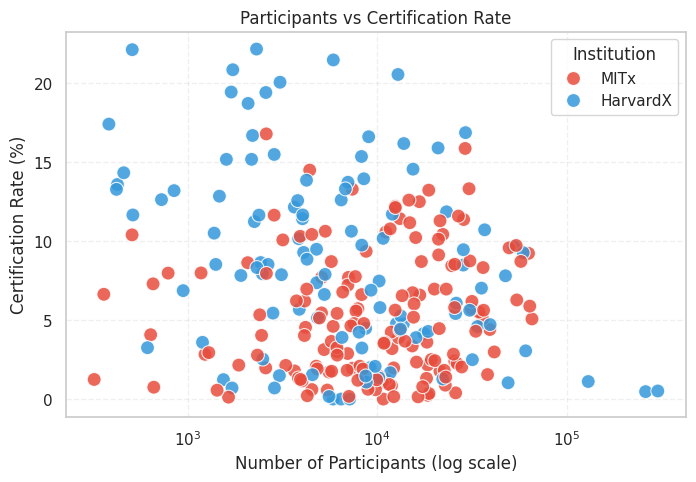

In [259]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='participants_(course_content_accessed)',
                y='certified_percent', hue='institution',   alpha=0.85, # Increase visibility
                                                           s=100, # Increase point size
                                                          palette=["#E74C3C", "#3498DB"])
plt.xscale('log')  # log scale because participant counts vary widely 10's
plt.title('Participants vs Certification Rate')
plt.xlabel('Number of Participants (log scale)')
plt.ylabel('Certification Rate (%)')
plt.legend(title='Institution')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

There is no strong correlation between the number of participants and certification rates, indicating that course size does not directly influence completion.

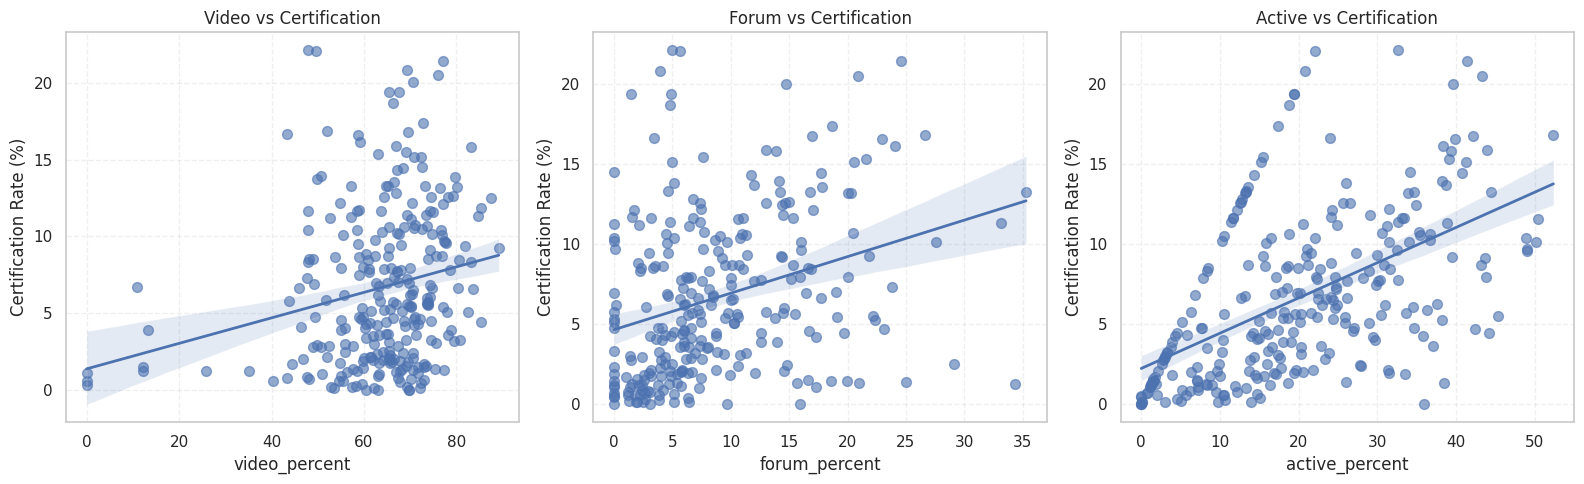

In [260]:
engagement_cols = ['video_percent', 'forum_percent', 'active_percent']

for col in engagement_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16,5))

for i, col in enumerate(engagement_cols):

    sns.regplot(
        data=df,
        x=col,
        y='certified_percent',
        scatter_kws={'alpha':0.6, 's':50},
        line_kws={'linewidth':2},
        ax=axes[i])

    axes[i].set_title(f'{col.replace("_percent","").capitalize()} vs Certification')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Certification Rate (%)')
    axes[i].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Video vs Certification:
Higher video engagement is associated with slightly higher certification rates, suggesting that active content interaction improves completion.

Forum vs Certification:
Forum participation shows a weak positive relationship with certification rates, indicating that discussion may support learner success.

Active vs Certification:
A strong positive relationship is observed between active participation and certification rates, highlighting engagement as a key factor in course completion.

/tmp/ipykernel_7392/4087562560.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='institution', y='age', ax=axes[1], palette=["#8B0000", "#145214"],
/tmp/ipykernel_7392/4087562560.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='institution', y='bachelor_percent', ax=axes[2], palette=["#8B0000", "#145214"],


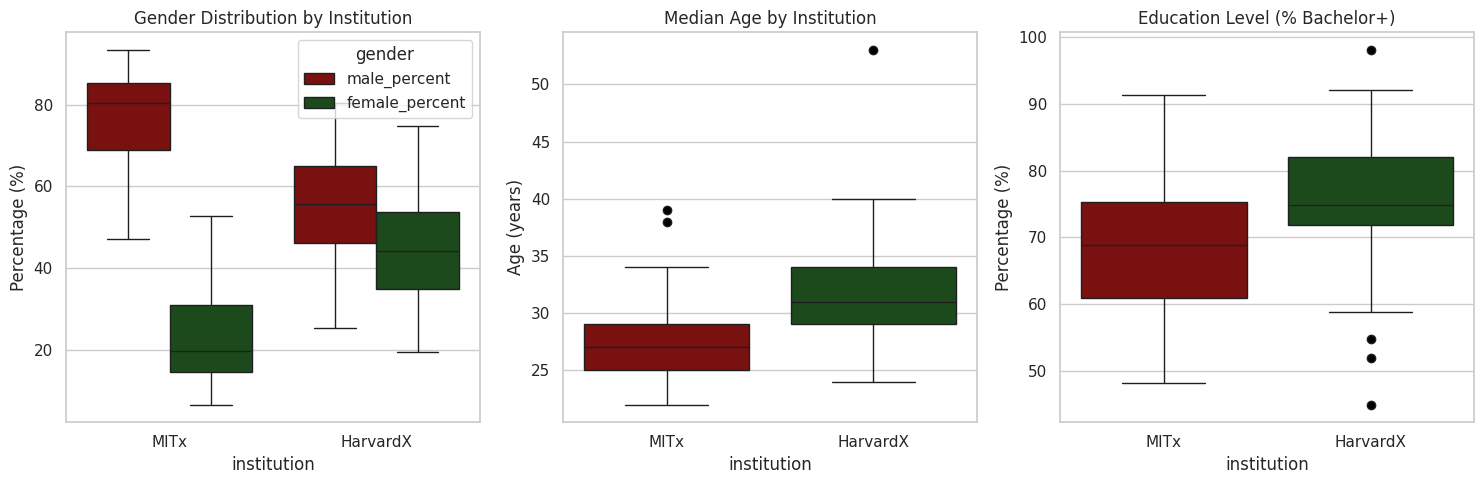

In [261]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

# Gender distribution
gender_melt = df.melt(id_vars='institution', value_vars=['male_percent', 'female_percent'],
var_name='gender', value_name='percent')

sns.boxplot(data=gender_melt, x='institution', y='percent', hue='gender', ax=axes[0], palette=["#8B0000", "#145214"] ,
            flierprops=dict(          # Customize outliers (points outside the box)
            markerfacecolor='black',     # Fill color of the points
))
axes[0].set_title('Gender Distribution by Institution')
axes[0].set_ylabel('Percentage (%)')

# Age distribution
sns.boxplot(data=df, x='institution', y='age', ax=axes[1], palette=["#8B0000", "#145214"],
            flierprops=dict(          # Customize outliers (points outside the box)
            markerfacecolor='black'))    # Fill color of the points

axes[1].set_title('Median Age by Institution')
axes[1].set_ylabel('Age (years)')

# Bachelor's degree or higher
sns.boxplot(data=df, x='institution', y='bachelor_percent', ax=axes[2], palette=["#8B0000", "#145214"],
            flierprops=dict(          # Customize outliers (points outside the box)
            markerfacecolor='black'   ))   # Fill color of the points
axes[2].set_title('Education Level (% Bachelor+)')
axes[2].set_ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

Gender Distribution:
MITx courses have a higher percentage of male participants, while HarvardX shows a more balanced gender distribution.

Median Age:
HarvardX courses tend to have slightly older participants compared to MITx, indicating differences in learner demographics.

Education Level (% Bachelor+):
HarvardX courses generally have a higher proportion of learners with a bachelor’s degree or higher, suggesting a more academically advanced audience.

/tmp/ipykernel_7392/3616582852.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cs, x='institution', y='certified_percent', palette=["#8B0000", "#C0392B"])


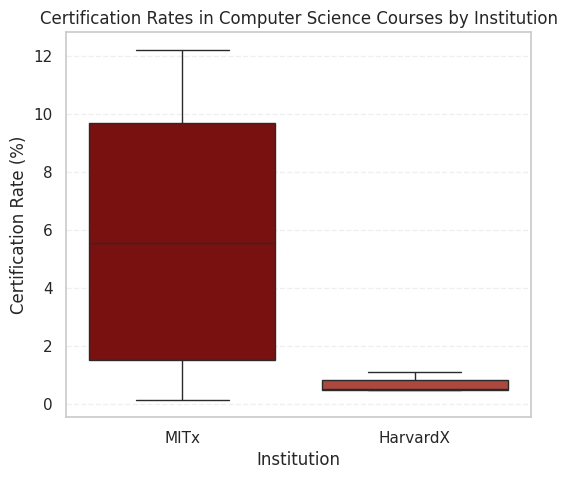

In [262]:
# Filter CS courses
df_cs = df[df['subject'].str.contains('Computer Science', case=False, na=False)].copy()

# Boxplot: certification rate by institution
plt.figure(figsize=(6,5))
sns.boxplot(data=df_cs, x='institution', y='certified_percent', palette=["#8B0000", "#C0392B"])
plt.title('Certification Rates in Computer Science Courses by Institution')
plt.xlabel('Institution')
plt.ylabel('Certification Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Certification in CS:
Certification rates in Computer Science courses are noticeably higher in MITx compared to HarvardX, supporting the hypothesis of institutional differences.

**Distribution of Certification Rate**

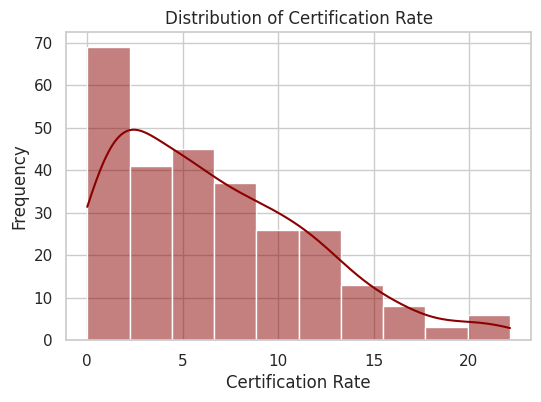

In [263]:
plt.figure(figsize=(6,4))
sns.histplot(df["certified_percent"], kde=True, color="#8B0000")
plt.title("Distribution of Certification Rate")
plt.xlabel("Certification Rate")
plt.ylabel("Frequency")
plt.show()

The distribution shows how certification rates vary across courses. Most courses tend to cluster within a certain range, with few extreme values.

**Certification Rate by Subject**

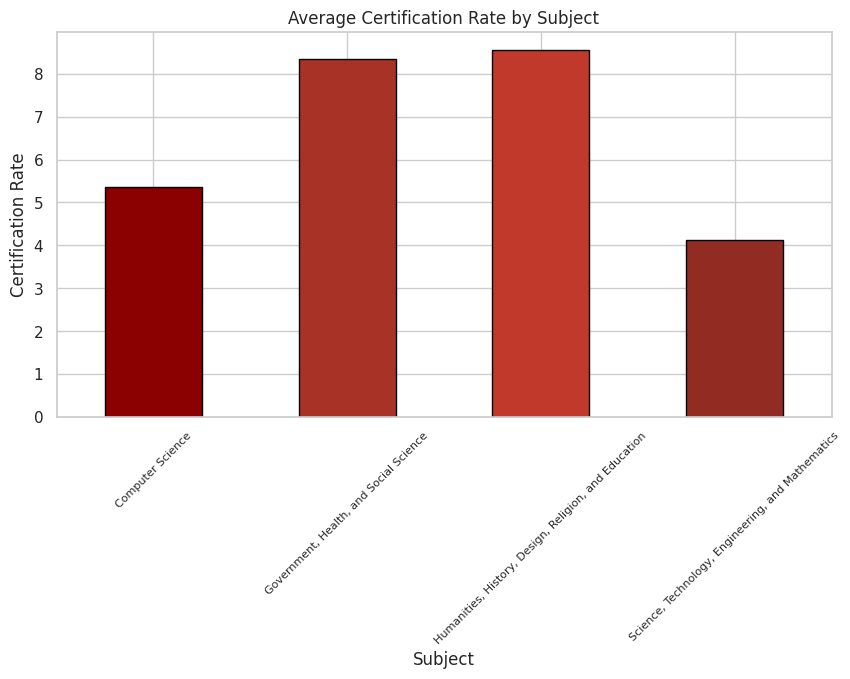

In [264]:
plt.figure(figsize=(10,5))

avg_cert = df.groupby("subject")["certified_percent"].mean()

colors = ["#8B0000", "#A93226", "#C0392B", "#922B21"]

avg_cert.plot(kind="bar", color=colors, edgecolor="black")

plt.title("Average Certification Rate by Subject")
plt.xlabel("Subject")
plt.ylabel("Certification Rate")

plt.xticks(rotation=45, fontsize=8)
plt.show()

Certification rates differ across subjects, indicating that some fields may be more accessible or engaging for learners than others.

**Certification Rate by Institution**

/tmp/ipykernel_7392/1409619065.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


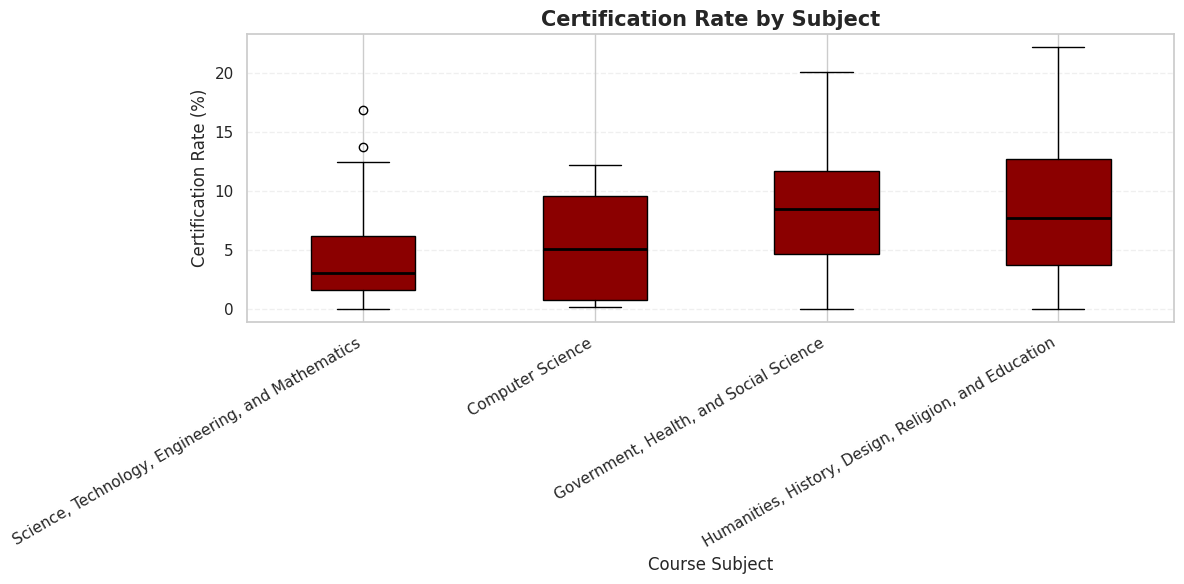

In [265]:
subjects = df["subject"].unique()

data_to_plot = [
    df[df["subject"] == sub]["certified_percent"].dropna()
    for sub in subjects
]


plt.figure(figsize=(12,6))

box = plt.boxplot(
    data_to_plot,
    labels=subjects,
    patch_artist=True
)


for patch in box['boxes']:
    patch.set_facecolor("#8B0000")

  # Loop through all median lines in the boxplot
for median in box['medians']:

    # Set the color of the median line to dark gray
    median.set_color("black")

    # Increase the thickness of the median line for better visibility
    median.set_linewidth(2)


plt.title("Certification Rate by Subject", fontsize=15, weight="bold")
plt.xlabel("Course Subject", fontsize=12)
plt.ylabel("Certification Rate (%)", fontsize=12)

plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Certification rates vary across subjects, with social sciences and humanities achieving higher completion compared to technical fields.

**Trimming Outliers**

In [266]:
def remove_outliers_all(df, cols):
    mask = pd.Series(True, index=df.index)

    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask &= (df[col] >= lower) & (df[col] <= upper)

    return df[mask]

cols = ['certified_percent', "bachelor_percent"]

print("Before:", df.shape)
df = remove_outliers_all(df, cols)
print("After:", df.shape)

Before: (274, 24)
After: (272, 24)


#Certification rates in Computer Science courses may vary between institutions (MIT and Harvard).

Box-Plot visualization

/tmp/ipykernel_7392/925203308.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


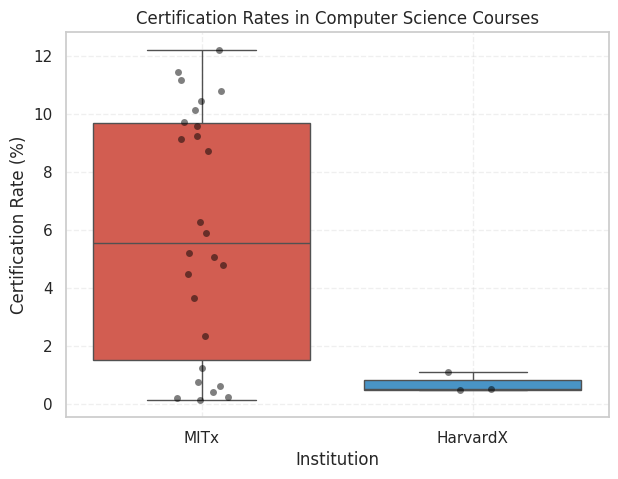

In [267]:
cs_df = df[df['subject'].str.contains('Computer Science', case=False, na=False)]
plt.figure(figsize=(7,5))

sns.boxplot(
    data=cs_df,
    x='institution',
    y='certified_percent',
    palette=["#E74C3C", "#3498DB"])

sns.stripplot(
    data=cs_df,
    x='institution',
    y='certified_percent',
    color='black',
    alpha=0.5)

plt.title('Certification Rates in Computer Science Courses')
plt.xlabel('Institution')
plt.ylabel('Certification Rate (%)')

plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

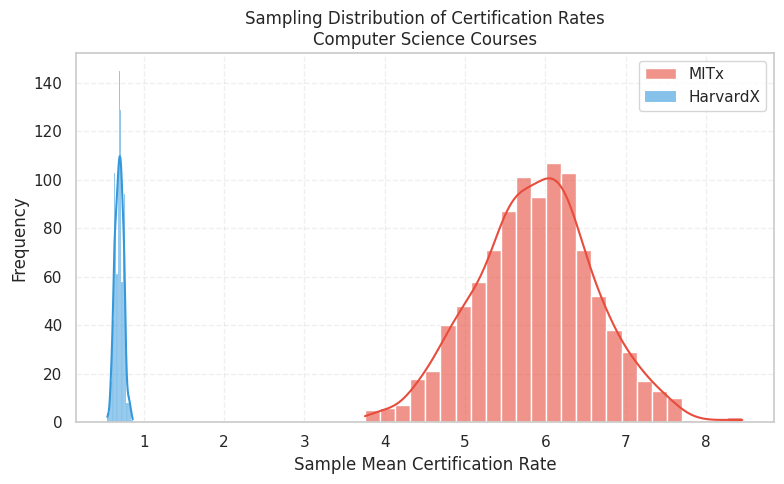

In [268]:
# Number of generated samples
n_samples = 1000

# Size of each random sample
sample_size = 30


# Lists to store sample means
mit_means = []
harvard_means = []

# Generate random samples with replacement
for _ in range(n_samples):

    # Random sample from MITx
    mit_sample = mit.sample(
        sample_size,
        replace=True)

    # Random sample from HarvardX
    harvard_sample = harvard.sample(
        sample_size,
        replace=True)

    # Store sample means
    mit_means.append(mit_sample.mean())
    harvard_means.append(harvard_sample.mean())


plt.figure(figsize=(8,5))

# MITx distribution
sns.histplot(mit_means,
            color="#E74C3C",
            label="MITx",
            kde=True,
            alpha=0.6)

# HarvardX distribution
sns.histplot(harvard_means,
            color="#3498DB",
            label="HarvardX",
            kde=True,
            alpha=0.6)

plt.title('Sampling Distribution of Certification Rates\n'
          'Computer Science Courses')

plt.xlabel('Sample Mean Certification Rate')
plt.ylabel('Frequency')

plt.legend()

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Grouping

In [269]:
# Research Hypothesis:
# H0 (Null Hypothesis):
# There is NO significant difference in certification rates
# between MITx and HarvardX Computer Science courses.
#
# H1 (Alternative Hypothesis):
# There IS a significant difference in certification rates
# between MITx and HarvardX Computer Science courses.
mit = cs_df[cs_df['institution'] == 'MITx']['certified_percent']

# Certification rates for HarvardX courses
harvard = cs_df[cs_df['institution'] == 'HarvardX']['certified_percent']

Display Descriptive Statistics

In [270]:
print("========== Descriptive Statistics ==========\n")

stats = cs_df.groupby('institution')['certified_percent'].agg(['mean', 'median', 'std', 'count'])

print(stats)

========== Descriptive Statistics ==========

                 mean  median       std  count
institution                                   
HarvardX     0.696667    0.51  0.358515      3
MITx         5.909231    5.53  4.213175     26


Levene’s Test (variance Equality)

In [271]:
stat, p_value = scipy.stats.levene(mit, harvard)

print(f"Levene Statistic: {stat}, p-value: {p_value}")

if p_value < 0.05:
    print("Reject null hypothesis: Variances are not equal.")
else:
    print("Fail to reject null hypothesis: Variances are equal.")

Levene Statistic: 8.983041322937394, p-value: 0.005785675469742378
Reject null hypothesis: Variances are not equal.


We use Welch's t-test (equal_var=False)

In [272]:
t_stat, p_value = ttest_ind(mit, harvard, equal_var=False)

print("\n========== T-Test Results ==========\n")

print("T-statistic :", t_stat)
print("P-value     :", p_value)


========== T-Test Results ==========

T-statistic : 6.119445036875024
P-value     : 1.5666945125425381e-06


Decision

In [273]:
alpha = 0.05

print("\n========== Hypothesis Decision ==========\n")

if p_value < alpha:

    print("Reject the Null Hypothesis (H0)")
    print("H1: There IS a statistically significant difference "
          "in certification rates between MITx and HarvardX "
          "Computer Science courses.")

else:

    print("Fail to Reject the Null Hypothesis (H0)")
    print("H0: There is NO statistically significant difference "
          "in certification rates between MITx and HarvardX "
          "Computer Science courses.")


========== Hypothesis Decision ==========

Reject the Null Hypothesis (H0)
H1: There IS a statistically significant difference in certification rates between MITx and HarvardX Computer Science courses.


#Research Question

Do certification rates differ significantly across different course subject areas?

In [274]:
# Group data by subject
groups = df.groupby('subject')['certified_percent'].apply(list)

# Perform One-Way ANOVA
f_stat, p_value = scipy.stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

# Decision
alpha = 0.05
if p_value < alpha:
    print("Reject H0 → Certification rates differ significantly across subjects.")
else:
    print("Fail to reject H0 → No significant difference in certification rates.")

F-statistic: 16.39819597645029
p-value: 8.192902295966381e-10
Reject H0 → Certification rates differ significantly across subjects.
